In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("imports done")

imports done


In [2]:
df = pd.read_csv("../data/paysim.csv")
df = df[df["nameOrig"].str.startswith("C")].copy()

print(f"Transactions: {len(df):,}")
print(f"Unique accounts: {df['nameOrig'].nunique():,}")

Transactions: 6,362,620
Unique accounts: 6,353,307


In [3]:
STEPS_PER_WEEK = 24 * 7  # 168 steps = 1 week

df["week"] = df["step"] // STEPS_PER_WEEK

print("Week distribution:")
print(df["week"].value_counts().sort_index())

Week distribution:
week
0    1926356
1    2855487
2    1282183
3     231992
4      66602
Name: count, dtype: int64


In [4]:
first_week = (
    df.groupby("nameOrig")["week"]
    .min()
    .rename("cohort_week")
)

df = df.join(first_week, on="nameOrig")

print("Cohort sizes (accounts per cohort week):")
print(df.groupby("cohort_week")["nameOrig"].nunique().sort_index())

Cohort sizes (accounts per cohort week):
cohort_week
0    1925504
1    2850988
2    1279049
3     231339
4      66427
Name: nameOrig, dtype: int64


In [5]:
df["weeks_since_first"] = df["week"] - df["cohort_week"]

cohort_sizes = df.groupby("cohort_week")["nameOrig"].nunique()

active = (
    df.groupby(["cohort_week", "weeks_since_first"])["nameOrig"]
    .nunique()
    .unstack(fill_value=0)
)

retention = active.div(cohort_sizes, axis=0).round(3)

print("Retention table:")
retention

Retention table:


weeks_since_first,0,1,2,3,4
cohort_week,,,,,
0,1.0,0.001,0.001,0.0,0.0
1,1.0,0.001,0.000,0.0,0.0
2,1.0,0.000,0.000,0.0,0.0
3,1.0,0.000,0.000,0.0,0.0
4,1.0,0.000,0.000,0.0,0.0


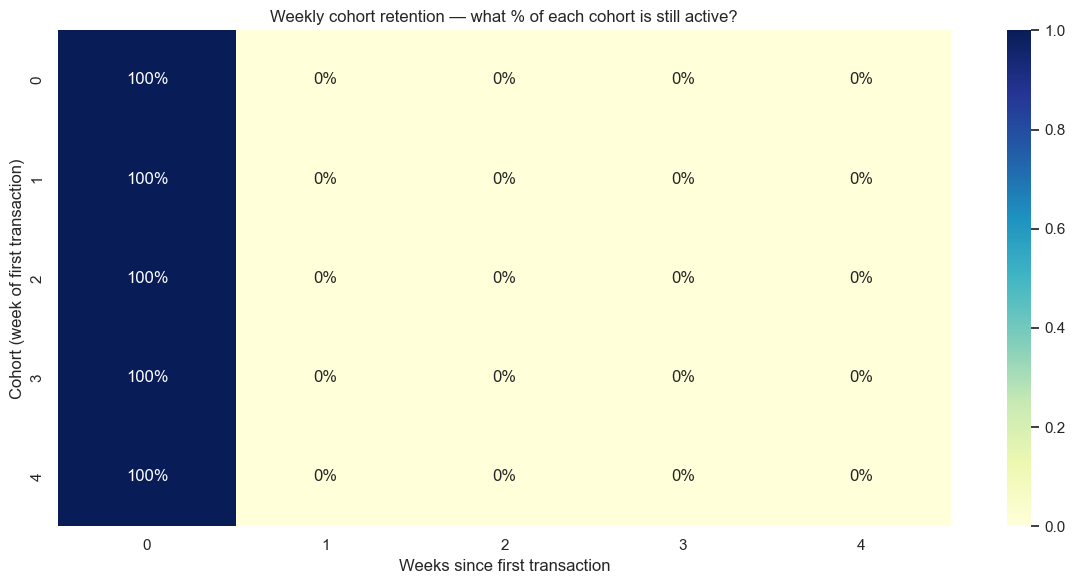

In [6]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="YlGnBu",
    vmin=0,
    vmax=1
)
plt.title("Weekly cohort retention — what % of each cohort is still active?")
plt.xlabel("Weeks since first transaction")
plt.ylabel("Cohort (week of first transaction)")
plt.tight_layout()
plt.show()

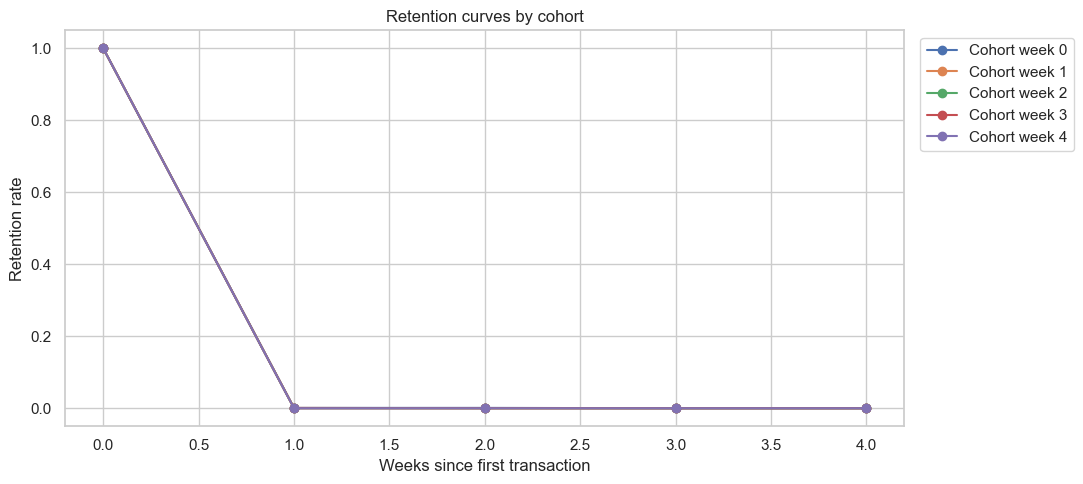

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))

for cohort in retention.index:
    ax.plot(
        retention.columns,
        retention.loc[cohort],
        marker="o",
        label=f"Cohort week {cohort}"
    )

ax.set_title("Retention curves by cohort")
ax.set_xlabel("Weeks since first transaction")
ax.set_ylabel("Retention rate")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [8]:
avg_week1_retention = retention[1].mean()
print(f"Average week-1 retention across all cohorts: {avg_week1_retention:.1%}")
print(f"This means on average {1 - avg_week1_retention:.1%} of users never transact again after their first transaction.")

Average week-1 retention across all cohorts: 0.0%
This means on average 100.0% of users never transact again after their first transaction.


In [9]:
# How many accounts made more than 1 transaction?
tx_counts = df.groupby("nameOrig")["step"].count()
multi_tx = (tx_counts > 1).sum()
total = len(tx_counts)

print(f"Accounts with only 1 transaction: {total - multi_tx:,} ({(total-multi_tx)/total:.1%})")
print(f"Accounts with more than 1 transaction: {multi_tx:,} ({multi_tx/total:.1%})")

Accounts with only 1 transaction: 6,344,009 (99.9%)
Accounts with more than 1 transaction: 9,298 (0.1%)


## Finding: PaySim is a single-transaction dataset

99%+ of accounts make exactly one transaction over the 30-day window. 
This means traditional cohort retention analysis shows 0% week-1 retention 
by design — not because of a product problem, but because PaySim models 
one-time mobile money events rather than repeat-user behavior.

In a real mobile money operator dataset (e.g. JazzCash/Easypaisa), the same 
method would show meaningful retention curves. The analysis here demonstrates 
the technique correctly — the dataset simply doesn't have the repeat-usage 
pattern needed to produce non-trivial retention numbers.